In [1]:
%pip install -U --trusted-host https://mirror-pypi.runflare.com -i https://mirror-pypi.runflare.com/simple/ skforecast

Looking in indexes: https://mirror-pypi.runflare.com/simple/
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data\jshare.csv')
data.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


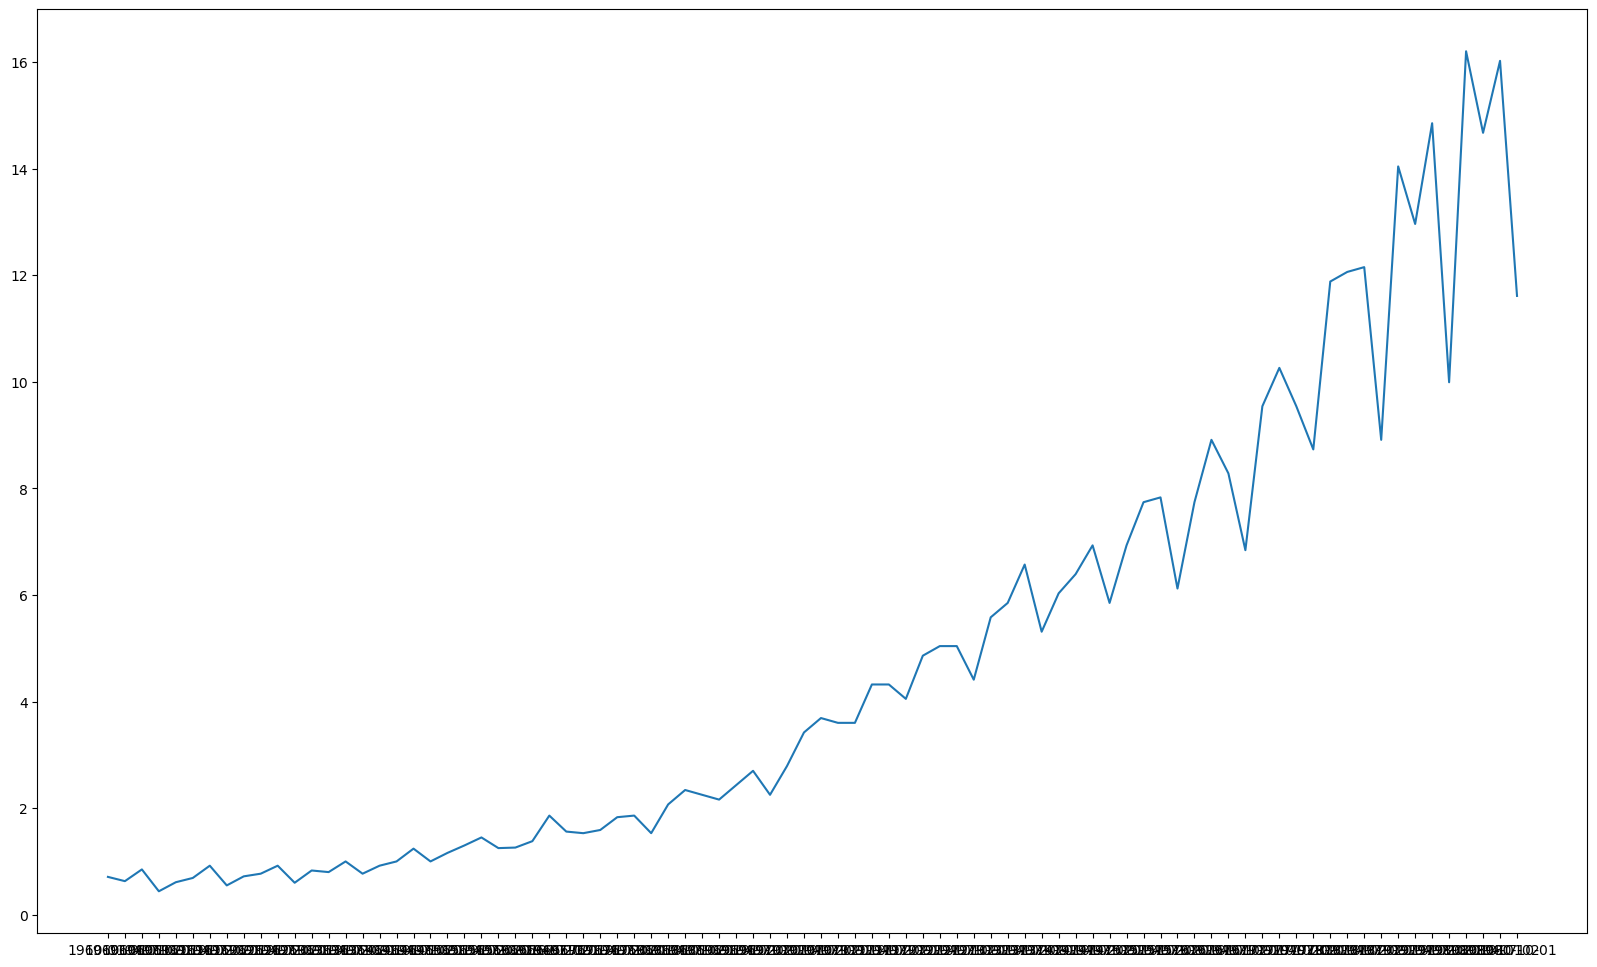

In [3]:
plt.figure(figsize=(20, 12))
plt.plot(data['date'], data['data'])
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

In [5]:
adfuller(data['data'])

(np.float64(2.742016573457468),
 1.0,
 11,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(82.63760283301104))

In [6]:
data['data'] = np.log(data['data'])

In [7]:
adfuller(data['data'])

(np.float64(-0.8040574622338496),
 np.float64(0.8179273123168573),
 4,
 79,
 {'1%': np.float64(-3.5159766913976376),
  '5%': np.float64(-2.898885703483903),
  '10%': np.float64(-2.5866935058484217)},
 np.float64(-142.1892728398871))

In [8]:
data['data'] = data['data'].diff(1)

In [9]:

data = data.drop(data.index[0])

data.head()

,date,data
1,1960-04-01,-0.119545
2,1960-07-02,0.299517
3,1960-10-01,-0.658462
4,1961-01-01,0.326684
5,1961-04-02,0.123233


In [10]:

adfuller(data['data'])

(np.float64(-4.317043945811826),
 np.float64(0.0004149731404440838),
 5,
 77,
 {'1%': np.float64(-3.518281134660583),
  '5%': np.float64(-2.899878185191432),
  '10%': np.float64(-2.5872229937594873)},
 np.float64(-140.7202208245293))

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [12]:
data2 = pd.read_csv('data\jshare.csv')
data2.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

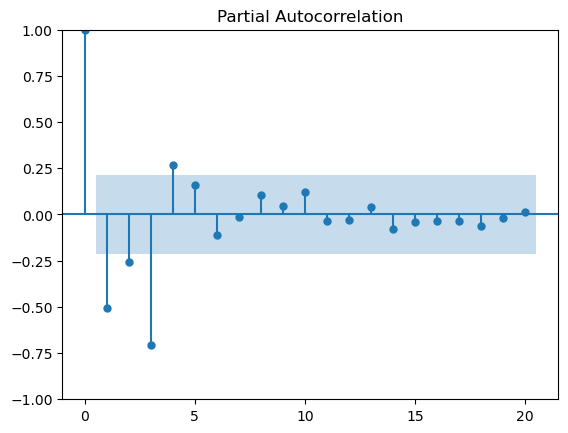

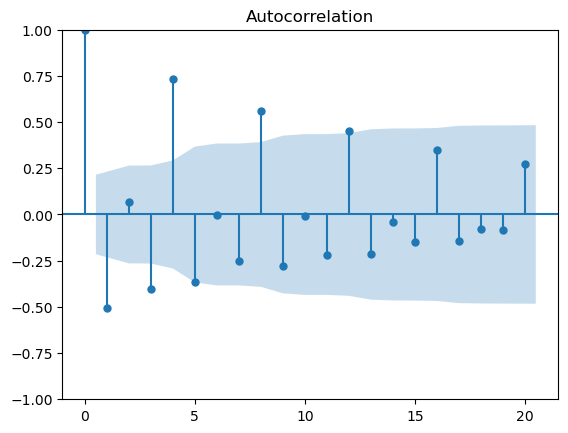

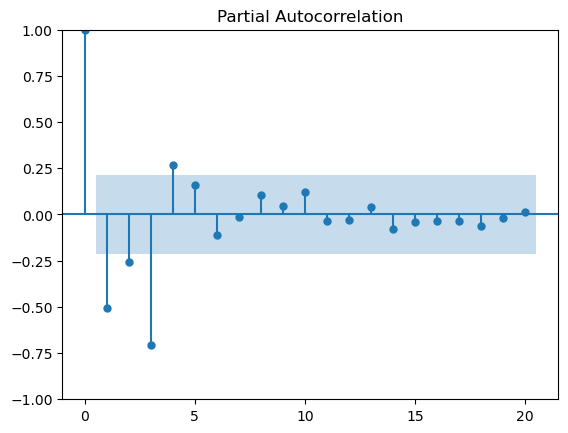

In [14]:
plot_acf(data['data'])
plot_pacf(data['data'])

In [15]:
data['data'] = data['data'].diff(1)

In [16]:
data = data.drop(data.index[0])

data.head()

,date,data
2,1960-07-02,0.419062
3,1960-10-01,-0.957978
4,1961-01-01,0.985146
5,1961-04-02,-0.203452
6,1961-07-02,0.164449


In [17]:
adfuller(data['data'])

(np.float64(-6.432063418573919),
 np.float64(1.687815584801043e-08),
 8,
 73,
 {'1%': np.float64(-3.5232835753964475),
  '5%': np.float64(-2.902030597326081),
  '10%': np.float64(-2.5883710883843123)},
 np.float64(-131.00848787159262))

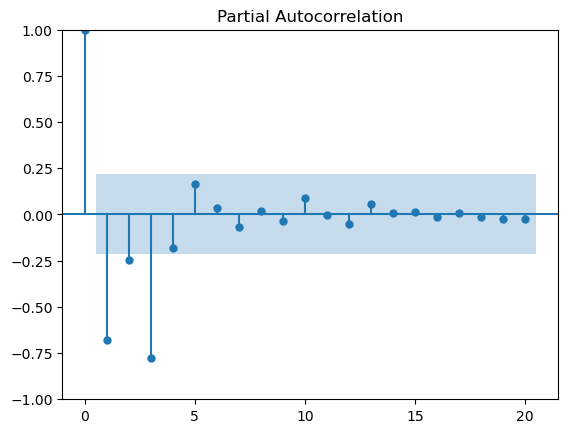

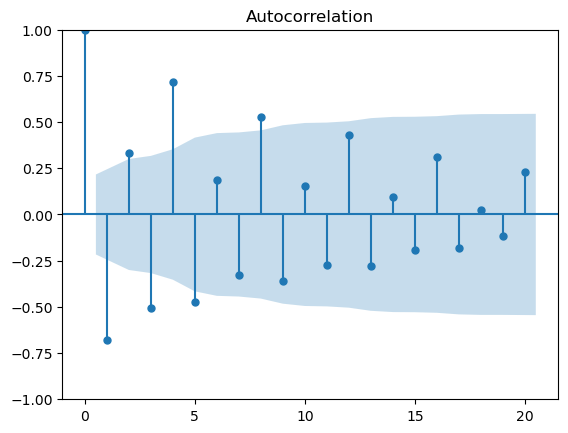

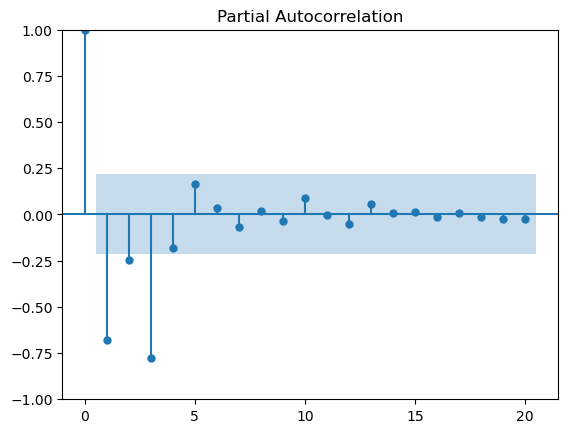

In [19]:
plot_acf(data['data'])
plot_pacf(data['data'])

In [21]:
model = SARIMAX(data2['data'], order=(3, 1, 3), seasonal_order=(2, 1, 2, 4))

In [22]:
res = model.fit()

c:\Users\USER\anaconda3\envs\my_cloned_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                   data   No. Observations:                   84
Model:             SARIMAX(3, 1, 3)x(2, 1, [1, 2], 4)   Log Likelihood                 -38.997
Date:                                Mon, 04 May 2026   AIC                             99.994
Time:                                        15:38:48   BIC                            126.058
Sample:                                             0   HQIC                           110.436
                                                 - 84                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6047      0.207     -7.753      0.000      -2.010      -1.199
ar.L2         -0.9997      0.329     -3.043      0.002      -1.644      -0.356
ar.L3         -0.1480      0.193     -0.765      0.444      -0.527       0.231
ma.L1          0.8467      0.688      1.231      0.218      -0.501       2.195
ma.L2          0.0175      0.491      0.036      0.972      -0.945       0.980
ma.L3         -0.6512      0.602     -1.082      0.279      -1.831       0.528
ar.S.L4       -0.3867      0.764     -0.506      0.613      -1.884       1.111
ar.S.L8       -0.7942      0.786     -1.011      0.312      -2.334       0.746
ma.S.L4        0.2813      0.757      0.372      0.710      -1.202       1.765
ma.S.L8        0.8737      0.809      1.080      0.280      -0.713       2.460
sigma2         0.1446      0.141      1.028      0.304      -0.131       0.420
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):                22.21
Prob(Q):                              0.77   Prob(JB):                         0.00
Heteroskedasticity (H):              26.50   Skew:                            -0.43
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.45
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [29]:
data2['sarimax'] = res.fittedvalues

In [31]:
data2.head()

,date,data,sarimax
0,1960-01-01,0.71,0.000
1,1960-04-01,0.63,0.710
2,1960-07-02,0.85,0.630
3,1960-10-01,0.44,0.850
4,1961-01-01,0.61,0.795


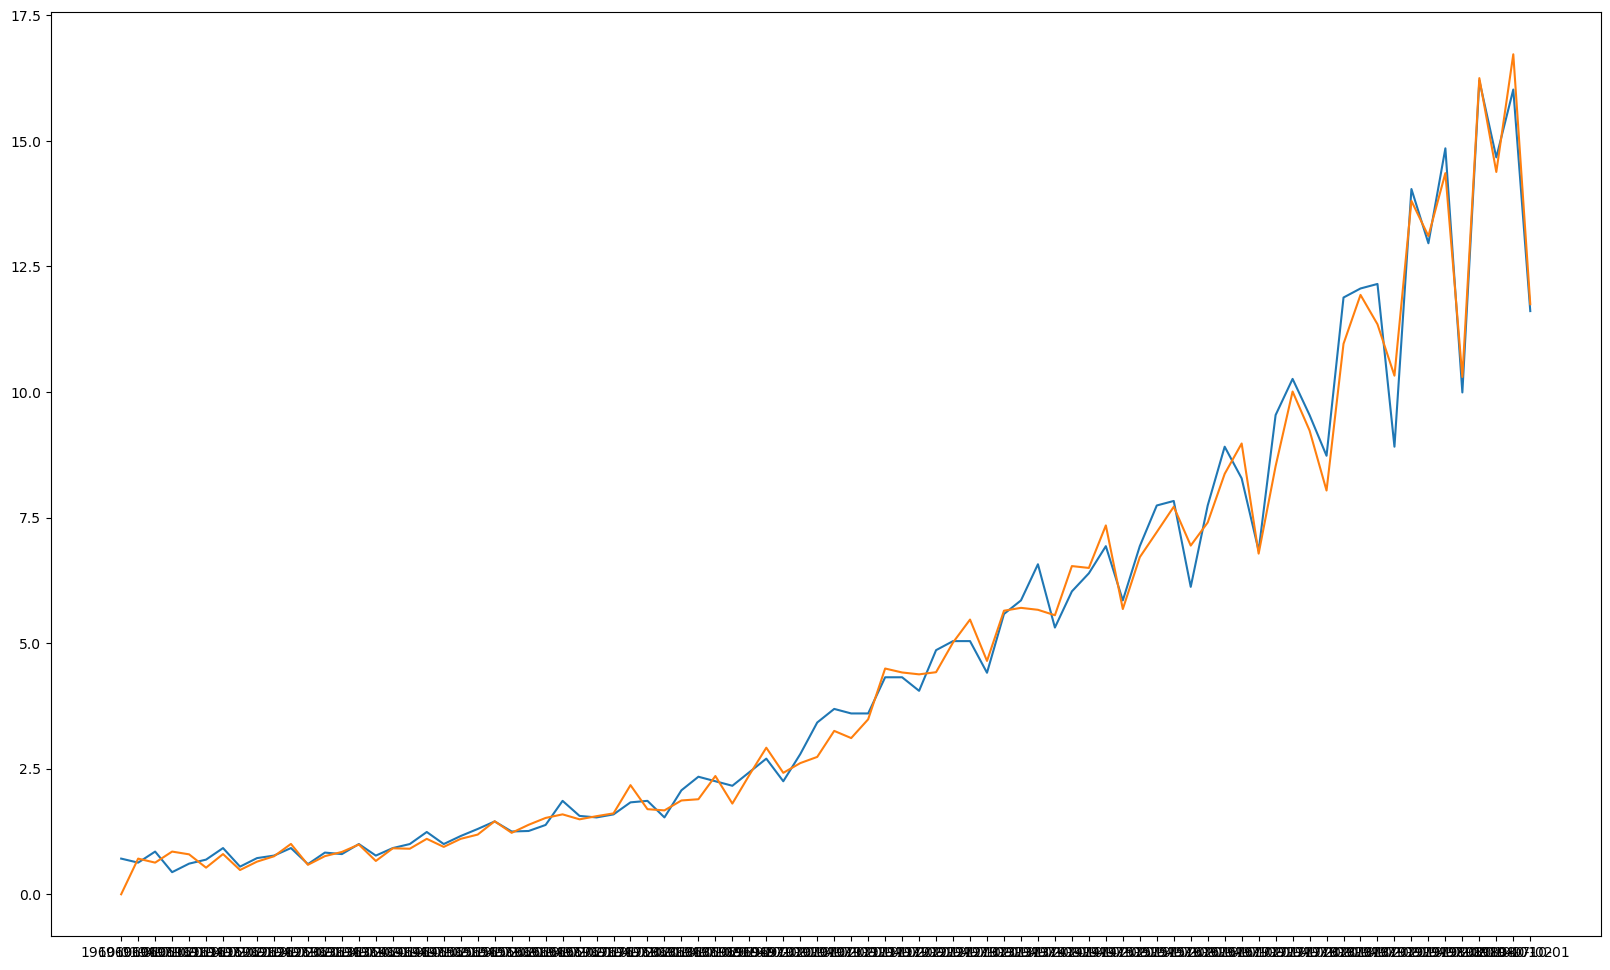

In [33]:
plt.figure(figsize=(20, 12))
plt.plot(data2['date'], data2['data'])
plt.plot(data2['date'], data2['sarimax'])
plt.show()

In [34]:
import itertools
import warnings

In [35]:
warnings.filterwarnings("ignore")

p = range(0, 4)
q = range(0, 4)
P = range(0, 2)
Q = range(0, 2)

d = 1
D = 1
s = 4

results = []

for param in itertools.product(p, q):
    for seasonal_param in itertools.product(P, Q):
        try:
            model = SARIMAX(
                data2['data'],
                order=(param[0], d, param[1]),
                seasonal_order=(seasonal_param[0], D, seasonal_param[1], s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit(disp=False)

            results.append([
                param,
                seasonal_param,
                model_fit.aic
            ])

        except:
            continue

results_df = pd.DataFrame(results, columns=["(p,q)", "(P,Q)", "AIC"])
results_df = results_df.sort_values("AIC")

print(results_df.head())

     (p,q)   (P,Q)        AIC
44  (2, 3)  (0, 0)  92.134345
45  (2, 3)  (0, 1)  92.468049
46  (2, 3)  (1, 0)  93.406551
60  (3, 3)  (0, 0)  94.082645
61  (3, 3)  (0, 1)  94.110090


In [40]:
r = pd.DataFrame(results)
r.head()
r.columns = ('(p,q)', '(P,Q)', 'AIC')
r.sort_values(by='AIC', ascending=True)

,"(p,q)","(P,Q)",AIC
44,"(2, 3)","(0, 0)",92.134345
45,"(2, 3)","(0, 1)",92.468049
46,"(2, 3)","(1, 0)",93.406551
60,"(3, 3)","(0, 0)",94.082645
61,"(3, 3)","(0, 1)",94.110090
...,...,...,...
35,"(2, 0)","(1, 1)",103.166891
1,"(0, 0)","(0, 1)",136.909257
3,"(0, 0)","(1, 1)",138.884277
2,"(0, 0)","(1, 0)",139.211242


In [41]:
model = SARIMAX(data2['data'], order=(2, 1, 3), seasonal_order=(0, 1, 0, 4))
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                               data   No. Observations:                   84
Model:             SARIMAX(2, 1, 3)x(0, 1, [], 4)   Log Likelihood                 -40.293
Date:                            Mon, 04 May 2026   AIC                             92.587
Time:                                    16:06:46   BIC                            106.803
Sample:                                         0   HQIC                            98.282
                                             - 84                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.4852      0.116    -12.807      0.000      -1.712      -1.258
ar.L2         -0.7910      0.131     -6.028      0.000      -1.048      -0.534
ma.L1          0.7698      0.809      0.952      0.341      -0.815       2.355
ma.L2         -0.1103      0.496     -0.223      0.824      -1.082       0.861
ma.L3         -0.7344      0.754     -0.974      0.330      -2.212       0.743
sigma2         0.1516      0.158      0.960      0.337      -0.158       0.461
===================================================================================
Ljung-Box (L1) (Q):                   0.34   Jarque-Bera (JB):                39.94
Prob(Q):                              0.56   Prob(JB):                         0.00
Heteroskedasticity (H):              25.97   Skew:                            -0.60
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [42]:
from sklearn.metrics import mean_squared_error
from math import sqrt

train_size = int(len(data2['data'])*0.8)
train, test = data2['data'][:train_size], data2['data'][train_size:]

results = []

for param in itertools.product(p, q):
    for seasonal_param in itertools.product(P, Q):
        try:
            model = SARIMAX(
                train,
                order=(param[0], d, param[1]),
                seasonal_order=(seasonal_param[0], D, seasonal_param[1], s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            model_fit = model.fit(disp=False)

            forecast = model_fit.forecast(steps=len(test))

            rmse = sqrt(mean_squared_error(test, forecast))

            results.append([
                param,
                seasonal_param,
                rmse
            ])

        except:
            continue

results_df = pd.DataFrame(results, columns=["(p,q)", "(P,Q)", "RMSE"])
results_df = results_df.sort_values("RMSE")

print(results_df.head())

     (p,q)   (P,Q)      RMSE
29  (1, 3)  (0, 1)  2.545142
31  (1, 3)  (1, 1)  2.551560
6   (0, 1)  (1, 0)  2.601673
7   (0, 1)  (1, 1)  2.607144
34  (2, 0)  (1, 0)  2.607533


In [43]:
model = SARIMAX(data2['data'], order=(1, 1, 3), seasonal_order=(0, 1, 1, 4))
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                data   No. Observations:                   84
Model:             SARIMAX(1, 1, 3)x(0, 1, [1], 4)   Log Likelihood                 -43.191
Date:                             Mon, 04 May 2026   AIC                             98.381
Time:                                     16:11:10   BIC                            112.598
Sample:                                          0   HQIC                           104.077
                                              - 84                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6859      0.337     -2.037      0.042      -1.346      -0.026
ma.L1         -0.1338      0.364     -0.368      0.713      -0.847       0.580
ma.L2         -0.2612      0.324     -0.806      0.420      -0.896       0.374
ma.L3         -0.1733      0.138     -1.256      0.209      -0.444       0.097
ma.S.L4        0.0133      0.174      0.077      0.939      -0.327       0.353
sigma2         0.1725      0.020      8.453      0.000       0.132       0.212
===================================================================================
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):                29.63
Prob(Q):                              0.61   Prob(JB):                         0.00
Heteroskedasticity (H):              31.86   Skew:                            -0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:

from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import grid_search_forecaster, backtesting_forecaster, TimeSeriesFold
from skforecast.utils import save_forecaster, load_forecaster
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5

KeyboardInterrupt: 

In [ ]:
data = pd.read_csv('data\h2o_exog.csv')
data.head(5)

,fecha,y,exog_1,exog_2
0,1992-04-01,0.379808,0.958792,1.166029
1,1992-05-01,0.361801,0.951993,1.117859
2,1992-06-01,0.410534,0.952955,1.067942
3,1992-07-01,0.483389,0.958078,1.097376
4,1992-08-01,0.475463,0.956370,1.122199


In [ ]:
data = data.rename(columns={'fecha': 'date', 'y': 'x'})
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
data = data.set_index('date')
data = data.asfreq('MS')
data = data.sort_index()

data.head(5)

,x,exog_1,exog_2
date,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199


In [ ]:
data.isnull().any(axis=1).sum()

np.int64(0)

In [ ]:
(data.index == pd.date_range(start=data.index.min(),
                             end=data.index.max(),
                             freq=data.index.freq)).all()

np.True_

In [ ]:
np.shape(data)

(195, 3)

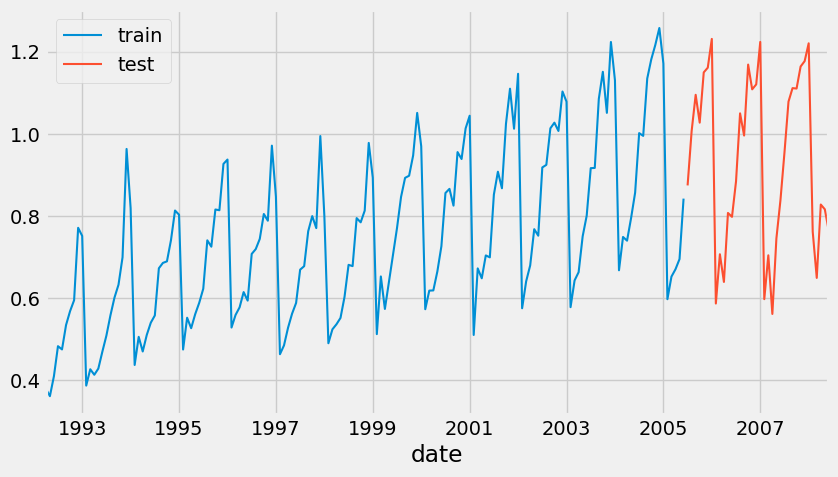

In [ ]:
steps = 36
data_train = data[:-steps]
data_test = data[-steps:]
fig, ax = plt.subplots(figsize=(9, 5))
data_train['x'].plot(ax=ax, label='train')
data_test['x'].plot(ax=ax, label='test')
ax.legend()

In [ ]:
forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(),
    lags=6
)
forecaster.fit(y=data_train['x'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [1 2 3 4 5 6] 
Window features: None 
Window size: 6 
Series name: x 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2005-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-05-03 21:06:25 
Last fit date: 2026-05-03 21:06:25 
Skforecast version: 0.22.0 
Python version: 3.13.9 
Forecaster id: None

In [ ]:
steps = 36
predicts = forecaster.predict(steps=steps)
predicts.head(5)

2005-07-01    0.870877
2005-08-01    0.879588
2005-09-01    0.988014
2005-10-01    1.004785
2005-11-01    1.023932
Freq: MS, Name: pred, dtype: float64

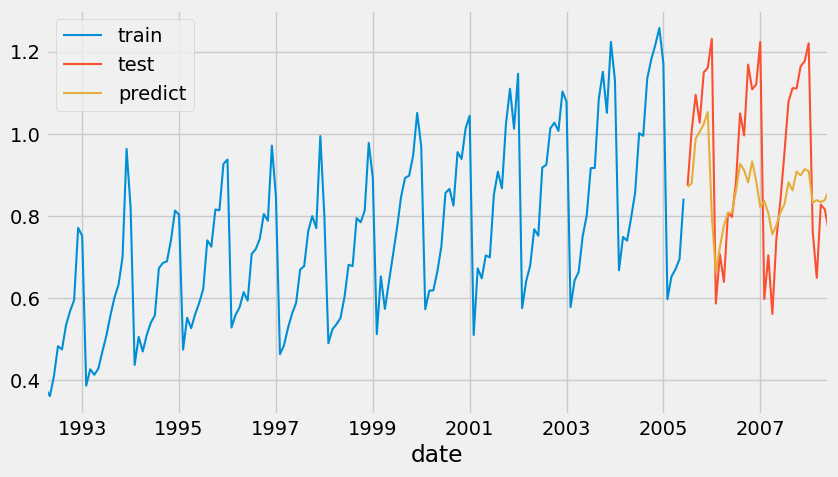

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
data_train['x'].plot(ax=ax, label='train')
data_test['x'].plot(ax=ax, label='test')
predicts.plot(ax=ax, label='predict')
ax.legend()

In [ ]:
error_mse = mean_squared_error(
    y_true=data_test['x'],
    y_pred=predicts
)

print(f"Test error (mse): {error_mse}")

Test error (mse): 0.032459464490219685


In [ ]:
forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(),
    lags=12
)
forecaster.fit(y=data_train['x'])
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12] 
Window features: None 
Window size: 12 
Series name: x 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2005-06-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-05-03 21:18:15 
Last fit date: 2026-05-03 21:18:15 
Skforecast version: 0.22.0 
Python version: 3.13.9 
Forecaster id: None

In [ ]:
predicts = forecaster.predict(steps=steps)

In [ ]:
error_mse = mean_squared_error(
    y_true=data_test['x'],
    y_pred=predicts)

print(f"Test error (mse): {error_mse}")

Test error (mse): 0.003887035233007789


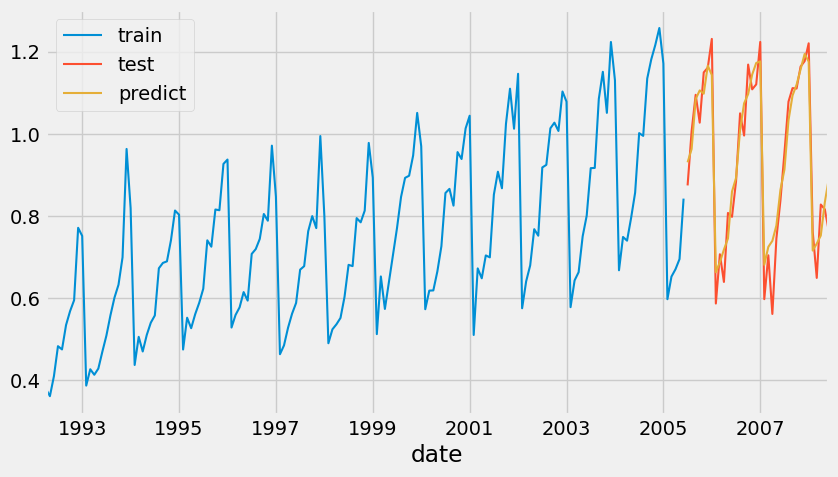

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
data_train['x'].plot(ax=ax, label='train')
data_test['x'].plot(ax=ax, label='test')
predicts.plot(ax=ax, label='predict')
ax.legend()

In [ ]:
lags_grid = [10, 20]

# Regressor's hyperparameters
param_grid = {'n_estimators': [100, 500],
              'max_depth': [3, 5, 10]}

cv = TimeSeriesFold(
    initial_train_size=int(len(data_train) * 0.5),
    fold_stride=24,
    steps=steps
)

results_grid = grid_search_forecaster(
    forecaster=forecaster,
    y=data_train['x'],
    param_grid=param_grid,
    lags_grid=lags_grid,
    metric='mean_squared_error',
    cv=cv,
    return_best=True,
    verbose=False
)

lags grid:   0%|          | 0/2 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

params grid:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
results_grid.head()

,lags,lags_label,params,mean_squared_error,max_depth,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 100}",0.019670,5,100
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 100}",0.019939,10,100
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 3, 'n_estimators': 500}",0.020637,3,500
3,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'n_estimators': 500}",0.020798,10,500
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 5, 'n_estimators': 500}",0.021028,5,500


In [ ]:
estimator = RandomForestRegressor(
    max_depth=5, n_estimators=100, random_state=123)
forecaster = ForecasterRecursive(
    estimator=estimator,
    lags=20
)

forecaster.fit(data_train['x'])

In [ ]:
predicts = forecaster.predict(steps=steps)

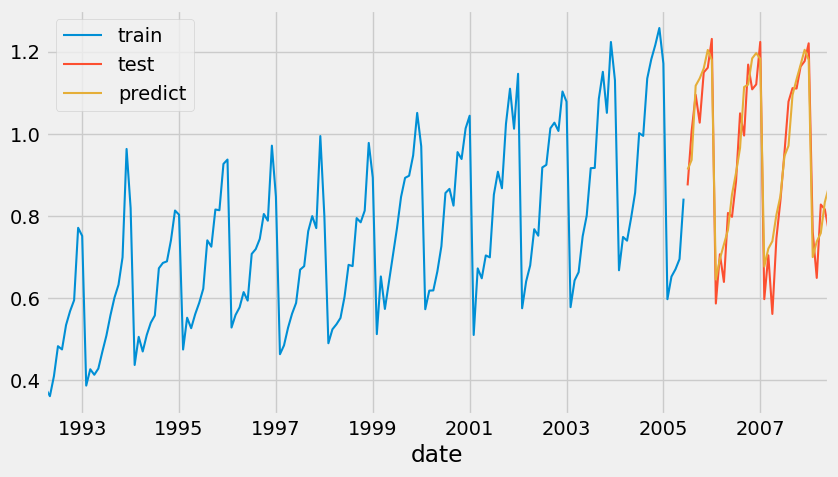

In [ ]:
fix, ax = plt.subplots(figsize=(9, 5))
data_train['x'].plot(ax=ax, label='train')
data_test['x'].plot(ax=ax, label='test')
predicts.plot(ax=ax, label='predict')
ax.legend()

In [ ]:
error_mse = mean_squared_error(
    y_true=data_test['x'],
    y_pred=predicts
)

print(f"Test error (mse): {error_mse}")

Test error (mse): 0.004478617116319269
